# 01 — Chunking and Retrieval

In a Retrieval-Augmented Generation (RAG) pipeline, raw documents must be split into smaller **chunks** before they can be embedded and stored in a vector database. The way you chunk your text has a direct impact on retrieval quality.

In this notebook you will:

1. Understand **why** chunking is necessary
2. Implement several **chunking strategies** (fixed-size, with overlap)
3. **Embed** chunks and store them in Qdrant
4. **Retrieve** relevant chunks for a given query and inspect similarity scores
5. Experiment with different parameters to see how they affect retrieval

---

## 1 · Setup

We import the libraries we need:
- **`qdrant_client`** — client for the Qdrant vector database
- **`openai`** — to compute dense vector embeddings via the octen-embedding API
- **`docling`** — to crawl and convert web pages into clean text
- **`dotenv`** — to load API credentials from `.env`

> **Prerequisite:** Make sure Qdrant is running at `localhost:6333`. Go back to `00_setup.ipynb`, if necessary.

In [3]:
from qdrant_client import QdrantClient, models
from docling.document_converter import DocumentConverter
import openai
import os
import json
import uuid
import hashlib
import textwrap
import numpy as np
from pathlib import Path
from urllib.parse import urljoin, urlparse
from dotenv import load_dotenv

import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

load_dotenv()

True

In [4]:
# Connect to local Qdrant instance
qdrant = QdrantClient(host="localhost", port=6333)
print("Qdrant collections:", [c.name for c in qdrant.get_collections().collections])

Qdrant collections: ['documents', 'gski_json_pdfs', 'nb_chars_4000', 'gski_xml_pdfs', 'gski_baseline', 'nb_chars_4000_overlap', 'nb_words_100', 'nb_chars_1000']


---
## 2 · Crawl Data from hpi.de

We crawl the **HPI homepage** and all **first-level subpages** using:
1. `requests` + `BeautifulSoup` to discover links
2. **Docling** to convert each page into clean Markdown text

The results are saved to `raw_data/data_crawled/` so we don't need to re-crawl on every notebook restart.

In [5]:
DATA_DIR = Path("raw_data/data_crawled")
DATA_DIR.mkdir(exist_ok=True)

BASE_URL = "https://hpi.de/"
EXCLUDE_PATHS = {"en"}  # skip the English mirror

# --- Step 1: Discover first-level subpages ---
resp = requests.get(BASE_URL, timeout=15)
soup = BeautifulSoup(resp.text, "html.parser")

subpages = set()
for a in soup.find_all("a", href=True):
    url = urljoin(BASE_URL, a["href"])
    parsed = urlparse(url)
    if parsed.netloc not in ("hpi.de", "www.hpi.de"):
        continue
    path = parsed.path.rstrip("/")
    segments = [s for s in path.split("/") if s]
    if len(segments) == 1 and segments[0] not in EXCLUDE_PATHS:
        subpages.add(f"https://hpi.de/{segments[0]}")

# Include the homepage itself
urls_to_crawl = [BASE_URL] + sorted(subpages)
print(f"Found {len(urls_to_crawl)} pages to crawl:")
for u in urls_to_crawl:
    print(f"  {u}")

Found 15 pages to crawl:
  https://hpi.de/
  https://hpi.de/agb
  https://hpi.de/barrierefreiheit
  https://hpi.de/datenschutz
  https://hpi.de/forschung
  https://hpi.de/hausordnung
  https://hpi.de/impact
  https://hpi.de/impressum
  https://hpi.de/institut
  https://hpi.de/ki-servicezentrum
  https://hpi.de/kontakt
  https://hpi.de/news-events
  https://hpi.de/studium
  https://hpi.de/suche
  https://hpi.de/widerruf


In [6]:
# --- Step 2: Crawl with Docling and save to files ---
converter = DocumentConverter()

for url in urls_to_crawl:
    # Derive a filename from the URL path
    parsed = urlparse(url)
    path = parsed.path.strip("/")
    filename = (path.replace("/", "_") if path else "homepage") + ".md"
    filepath = DATA_DIR / filename

    if filepath.exists():
        print(f"  [skip] {filename} (already exists)")
        continue

    try:
        result = converter.convert(url)
        md_text = result.document.export_to_markdown()
        filepath.write_text(md_text, encoding="utf-8")
        print(f"  [ok]   {filename} ({len(md_text)} chars)")
    except Exception as e:
        print(f"  [fail] {filename}: {e}")

print(f"\nDone. Files saved in {DATA_DIR.resolve()}")

  [skip] homepage.md (already exists)
  [skip] agb.md (already exists)
  [skip] barrierefreiheit.md (already exists)
  [skip] datenschutz.md (already exists)
  [skip] forschung.md (already exists)
  [skip] hausordnung.md (already exists)
  [skip] impact.md (already exists)
  [skip] impressum.md (already exists)
  [skip] institut.md (already exists)
  [skip] ki-servicezentrum.md (already exists)
  [skip] kontakt.md (already exists)
  [skip] news-events.md (already exists)
  [skip] studium.md (already exists)
  [skip] suche.md (already exists)
  [skip] widerruf.md (already exists)

Done. Files saved in /home/hanmul/Workshops/workshop-ragV2/notebooks/raw_data/data_crawled


### Step 2b: Download images from crawled pages

The Docling converter extracts **text only** (`export_to_markdown()`).
For multimodal embedding models (notebook 02) we also need images.

This cell revisits the same URLs and downloads `<img>` tags using
BeautifulSoup. We skip tiny images (< 5 KB — usually icons, spacers,
tracking pixels) to keep only meaningful content images.

In [ ]:
# --- Step 2b: Download images from crawled pages ---
IMG_DIR = DATA_DIR / "images"
IMG_DIR.mkdir(exist_ok=True)

MIN_SIZE_BYTES = 5_000          # skip tiny images (icons, spacers)
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".gif", ".svg"}
seen_urls = set()
total_saved = 0

for page_url in urls_to_crawl:
    try:
        page_resp = requests.get(page_url, timeout=15)
        page_soup = BeautifulSoup(page_resp.text, "html.parser")
    except Exception as e:
        print(f"  [fail] could not fetch {page_url}: {e}")
        continue

    page_label = urlparse(page_url).path.strip("/").replace("/", "_") or "homepage"
    img_idx = 0

    for img_tag in page_soup.find_all("img", src=True):
        img_url = urljoin(page_url, img_tag["src"])

        # Deduplicate
        if img_url in seen_urls:
            continue
        seen_urls.add(img_url)

        # Check extension
        img_path = urlparse(img_url).path.lower()
        ext = Path(img_path).suffix
        if ext not in IMG_EXTENSIONS:
            continue

        try:
            img_resp = requests.get(img_url, timeout=15)
            img_resp.raise_for_status()
        except Exception:
            continue

        # Skip tiny images
        if len(img_resp.content) < MIN_SIZE_BYTES:
            continue

        fname = f"{page_label}_{img_idx:03d}{ext}"
        (IMG_DIR / fname).write_bytes(img_resp.content)
        img_idx += 1
        total_saved += 1

    if img_idx:
        print(f"  {page_label}: saved {img_idx} images")

print(f"\nDone. {total_saved} images saved in {IMG_DIR.resolve()}")

In [7]:
# --- Step 3: Load crawled files into DOCUMENTS dict ---
DOCUMENTS = {}
for filepath in sorted(DATA_DIR.glob("*.md")):
    text = filepath.read_text(encoding="utf-8").strip()
    if text:  # skip empty files
        DOCUMENTS[filepath.name] = text

print(f"Loaded {len(DOCUMENTS)} documents from {DATA_DIR}/\n")
for name, text in DOCUMENTS.items():
    print(f"  {name}: {len(text)} chars, ~{len(text.split())} words")

Loaded 15 documents from raw_data/data_crawled/

  agb.md: 9658 chars, ~1156 words
  barrierefreiheit.md: 5319 chars, ~554 words
  datenschutz.md: 9802 chars, ~1131 words
  forschung.md: 4227 chars, ~378 words
  hausordnung.md: 9218 chars, ~1184 words
  homepage.md: 6634 chars, ~702 words
  impact.md: 2714 chars, ~309 words
  impressum.md: 2670 chars, ~282 words
  institut.md: 2850 chars, ~302 words
  ki-servicezentrum.md: 9355 chars, ~963 words
  kontakt.md: 2122 chars, ~216 words
  news-events.md: 3176 chars, ~338 words
  studium.md: 4193 chars, ~484 words
  suche.md: 90 chars, ~11 words
  widerruf.md: 3250 chars, ~379 words


---
## 3 · Chunking Strategies

We will compare **five different chunking strategies** and see how each one affects retrieval quality. For every strategy we will:

1. Define the chunking function  
2. Show example chunks from one document  
3. Index **all** documents into Qdrant and retrieve the top results for:

> *"Welche Services bietet das KI-Servicezentrum an und wo kann ich weitere Informationen zu den Services finden?"*

In [8]:
# --- Shared helpers for all strategies ---

# ── Embedding setup (octen, credentials from .env) ──
EMBEDDING_MODEL = os.environ["OPENAI_EMBEDDING_MODEL"]  # octen-embedding-8b
EMBEDDING_DIM = int(os.environ["OPENAI_EMBEDDING_DIM"])  # 4096

_embed_client = openai.OpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
)


def embed(texts):
    """Embed a string or list of strings via the octen embedding API.
    Returns a list of numpy arrays.
    """
    if isinstance(texts, str):
        texts = [texts]
    resp = _embed_client.embeddings.create(model=EMBEDDING_MODEL, input=texts)
    return [np.array(d.embedding) for d in resp.data]


print(f"Embedding model: {EMBEDDING_MODEL}  |  dim = {EMBEDDING_DIM}")

# ── Other shared config ──
QUERY = "Welche Services bietet das KI-Servicezentrum an und wo kann ich weitere Informationen zu den Services finden?"

BATCH_SIZE = 100  # max points per upsert call to stay under payload limit

# Collect similarity scores for comparison plots
strategy_scores: dict[str, list[float]] = {}


def make_point_id(doc_name: str, chunk_idx: int) -> str:
    """Create a deterministic UUID from document name + chunk index."""
    raw = f"{doc_name}_{chunk_idx}"
    hash_hex = hashlib.sha256(raw.encode()).hexdigest()
    return str(uuid.UUID(hash_hex[:32]))


def index_and_search(strategy_name: str, chunk_fn, top_k: int = 5):
    """Chunk all documents, index in Qdrant, and search for QUERY.
    
    Returns a sorted (descending) list of ALL similarity scores.
    """
    collection = f"nb_{strategy_name}"
    
    # (Re-)create collection
    if qdrant.collection_exists(collection):
        qdrant.delete_collection(collection)
    qdrant.create_collection(
        collection_name=collection,
        vectors_config=models.VectorParams(size=EMBEDDING_DIM, distance=models.Distance.COSINE),
    )
    
    # Chunk & upsert all documents
    all_points = []
    total_chunks = 0
    for doc_name, text in DOCUMENTS.items():
        doc_chunks = chunk_fn(text)
        total_chunks += len(doc_chunks)
        embeddings = embed(doc_chunks)
        for idx, (chunk, emb) in enumerate(zip(doc_chunks, embeddings)):
            all_points.append(models.PointStruct(
                id=make_point_id(f"{collection}_{doc_name}", idx),
                vector=emb.tolist(),
                payload={"document": doc_name, "chunk_index": idx, "content": chunk},
            ))
    
    # Upsert in batches to avoid exceeding Qdrant payload size limit
    for i in range(0, len(all_points), BATCH_SIZE):
        batch = all_points[i : i + BATCH_SIZE]
        qdrant.upsert(collection_name=collection, points=batch)
    print(f"Indexed {len(all_points)} chunks from {len(DOCUMENTS)} documents into '{collection}'")
    print(f"Average chunks per document: {total_chunks / len(DOCUMENTS):.1f}")
    
    # Retrieve ALL scores for comparison plots
    query_vector = embed(QUERY)[0].tolist()
    all_results = qdrant.query_points(
        collection_name=collection, query=query_vector, limit=len(all_points)
    ).points
    all_scores = sorted([r.score for r in all_results], reverse=True)
    
    # Store for later plotting
    strategy_scores[strategy_name] = all_scores
    
    return all_scores

Embedding model: octen-embedding-8b  |  dim = 4096


### 3.1 — Paragraph-based chunking

Split text on **blank lines** (double newlines). Each paragraph becomes its own chunk. This preserves natural document structure but produces chunks of very different sizes.

In [9]:
def chunk_by_paragraph(text: str) -> list[str]:
    """Split text into chunks at paragraph boundaries (blank lines)."""
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    return paragraphs


# --- Show example chunks ---
sample_name = list(DOCUMENTS.keys())[0]
sample = DOCUMENTS[sample_name]
demo_chunks = chunk_by_paragraph(sample)

print(f"Document: {sample_name}")
print(f"Total paragraphs: {len(demo_chunks)}\n")
for i, chunk in enumerate(demo_chunks[:5]):
    print(f"--- Chunk {i} ({len(chunk)} chars, {len(chunk.split())} words) ---")
    print(chunk[:300])
    print()

Document: agb.md
Total paragraphs: 12

--- Chunk 0 (5 chars, 2 words) ---
# AGB

--- Chunk 1 (26 chars, 4 words) ---
1. [HPI](/)
2. [AGB](/agb)

--- Chunk 2 (43 chars, 6 words) ---
## AGBs für Weiterbildungsprogramme des HPI

--- Chunk 3 (28 chars, 4 words) ---
### I. Allgemeine Regelungen

--- Chunk 4 (2423 chars, 290 words) ---
1. **Geltungsbereich** Diese Allgemeinen Geschäftsbedingungen regeln das Vertragsverhältnis zwischen der Hasso-Plattner-Institut für Digital Engineering gGmbH (im Folgenden: das HPI) und ihren Kunden abschließend. Allgemeine Geschäftsbedingungen des Kunden haben keine Gültigkeit, selbst dann, wenn d



In [10]:
index_and_search("paragraph", chunk_by_paragraph)

Indexed 384 chunks from 15 documents into 'nb_paragraph'
Average chunks per document: 25.6


[0.8261137,
 0.65972245,
 0.6430452,
 0.6275116,
 0.62526286,
 0.60825115,
 0.6081649,
 0.5821787,
 0.5694597,
 0.5692185,
 0.5560587,
 0.5547564,
 0.54976606,
 0.52413327,
 0.5171641,
 0.5139893,
 0.513909,
 0.51306623,
 0.510938,
 0.5099648,
 0.50954795,
 0.5092143,
 0.50363606,
 0.49382985,
 0.49102536,
 0.4768448,
 0.46737033,
 0.4600125,
 0.4458794,
 0.44486815,
 0.43442118,
 0.4093173,
 0.39350873,
 0.38919538,
 0.3689056,
 0.35513425,
 0.34820864,
 0.34328857,
 0.34147936,
 0.337303,
 0.33709472,
 0.32698393,
 0.3269276,
 0.32273468,
 0.31733972,
 0.31546915,
 0.31390536,
 0.3114084,
 0.31126016,
 0.31076273,
 0.30927193,
 0.29782432,
 0.29703423,
 0.29434553,
 0.29434553,
 0.29381484,
 0.2934962,
 0.29305482,
 0.2918118,
 0.2912975,
 0.29112375,
 0.28691038,
 0.28603497,
 0.28582126,
 0.2836275,
 0.2825456,
 0.28177035,
 0.28131208,
 0.27937728,
 0.27804178,
 0.27775955,
 0.27744356,
 0.27741235,
 0.27575576,
 0.27487016,
 0.27421308,
 0.27290198,
 0.27101097,
 0.27067435,
 0.2

### 3.2 — Fixed word count (max 100 words)

Split text into chunks of at most **100 words**. Simple and deterministic, but may cut sentences in the middle.

In [11]:
def chunk_by_words(text: str, max_words: int = 100) -> list[str]:
    """Split text into chunks of at most max_words words."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), max_words):
        chunk = " ".join(words[i : i + max_words])
        chunks.append(chunk)
    return chunks


# --- Show example chunks ---
demo_chunks = chunk_by_words(sample, max_words=100)

print(f"Document: {sample_name}")
print(f"Total chunks: {len(demo_chunks)}\n")
for i, chunk in enumerate(demo_chunks[:3]):
    print(f"--- Chunk {i} ({len(chunk)} chars, {len(chunk.split())} words) ---")
    print(chunk[:300])
    print()

Document: agb.md
Total chunks: 12

--- Chunk 0 (857 chars, 100 words) ---
# AGB 1. [HPI](/) 2. [AGB](/agb) ## AGBs für Weiterbildungsprogramme des HPI ### I. Allgemeine Regelungen 1. **Geltungsbereich** Diese Allgemeinen Geschäftsbedingungen regeln das Vertragsverhältnis zwischen der Hasso-Plattner-Institut für Digital Engineering gGmbH (im Folgenden: das HPI) und ihren K

--- Chunk 1 (768 chars, 100 words) ---
es sich dabei um die Verletzung einer wesentlichen Pflicht handelt. In Fällen einer leicht fahrlässigen Verletzung einer wesentlichen Pflicht ist die Haftung beschränkt auf den vertragstypischen und vorhersehbaren Schaden.ct. Im Übrigen haftet das HPI nur im Falle von Vorsatz oder grober Fahrlässigk

--- Chunk 2 (847 chars, 100 words) ---
durch den Kunden vor. Erstellt das HPI für den Kunden urheberrechtsfähige Werke (z.B. Schulungsunterlagen und Präsentationen), so wird dem Kunden aufschiebend bedingt durch die vollständige Erfüllung sämtlicher Zahlungsverpflichtungen und sowei

In [12]:
index_and_search("words_100", lambda text: chunk_by_words(text, max_words=100))

Indexed 92 chunks from 15 documents into 'nb_words_100'
Average chunks per document: 6.1


[0.7255778,
 0.5790984,
 0.5739995,
 0.5634765,
 0.5309272,
 0.5297778,
 0.5139488,
 0.49322885,
 0.4895478,
 0.37432668,
 0.37398207,
 0.31078306,
 0.30835927,
 0.3073761,
 0.3037882,
 0.28113312,
 0.25206542,
 0.24742909,
 0.24664833,
 0.24556655,
 0.24531224,
 0.24529713,
 0.24404928,
 0.23770139,
 0.23493955,
 0.23347373,
 0.23145282,
 0.22805868,
 0.22654998,
 0.22378051,
 0.22327664,
 0.22325417,
 0.21934108,
 0.21690887,
 0.21524605,
 0.21426472,
 0.21390362,
 0.2118907,
 0.20907354,
 0.20584925,
 0.2030494,
 0.20292649,
 0.20251954,
 0.20181057,
 0.20105349,
 0.19928205,
 0.19925228,
 0.19854379,
 0.19835949,
 0.1960752,
 0.1945045,
 0.19374213,
 0.18959516,
 0.18916273,
 0.18845098,
 0.18648627,
 0.18371011,
 0.18361506,
 0.1832278,
 0.18094799,
 0.18066424,
 0.17927393,
 0.17868936,
 0.17850849,
 0.17223275,
 0.17179346,
 0.1709764,
 0.16977187,
 0.16386607,
 0.16350661,
 0.16254783,
 0.1622658,
 0.16107371,
 0.15919511,
 0.15781906,
 0.15204789,
 0.1515775,
 0.14745153,
 0.1

### 3.3 — Fixed character count (max 1 000 chars)

Split text into chunks of at most **1 000 characters**, breaking at the last space before the limit so words aren't split.

In [13]:
def chunk_by_chars(text: str, max_chars: int = 1000, overlap: int = 0) -> list[str]:
    """Split text into chunks of at most max_chars characters.
    
    Breaks at the last whitespace before the limit to avoid splitting words.
    Optionally overlaps by `overlap` characters.
    """
    chunks = []
    stride = max(1, max_chars - overlap)
    start = 0
    while start < len(text):
        end = start + max_chars
        if end >= len(text):
            chunk = text[start:].strip()
            if chunk:
                chunks.append(chunk)
            break
        # Find last space before the limit
        space_idx = text.rfind(" ", start, end)
        if space_idx <= start:
            space_idx = end  # no space found, hard cut
        chunk = text[start:space_idx].strip()
        if chunk:
            chunks.append(chunk)
        # Advance by stride, but respect the actual break point
        start = max(start + 1, space_idx - overlap)
    return chunks


# --- Show example chunks (1000 chars) ---
demo_chunks = chunk_by_chars(sample, max_chars=1000)

print(f"Document: {sample_name}")
print(f"Total chunks: {len(demo_chunks)}\n")
for i, chunk in enumerate(demo_chunks[:3]):
    print(f"--- Chunk {i} ({len(chunk)} chars, {len(chunk.split())} words) ---")
    print(chunk[:300])
    print()

Document: agb.md
Total chunks: 10

--- Chunk 0 (995 chars, 118 words) ---
# AGB

1. [HPI](/)
2. [AGB](/agb)

## AGBs für Weiterbildungsprogramme des HPI

### I. Allgemeine Regelungen

1. **Geltungsbereich** Diese Allgemeinen Geschäftsbedingungen regeln das Vertragsverhältnis zwischen der Hasso-Plattner-Institut für Digital Engineering gGmbH (im Folgenden: das HPI) und ihr

--- Chunk 1 (998 chars, 128 words) ---
Pflicht ist die Haftung beschränkt auf den vertragstypischen und vorhersehbaren Schaden.ct. Im Übrigen haftet das HPI nur im Falle von Vorsatz oder grober Fahrlässigkeit oder bei der schuldhaften Verletzung von Leben, Körper oder Gesundheit. Haftungsansprüche wegen leichter Fahrlässigkeit verjähren 

--- Chunk 2 (985 chars, 114 words) ---
zur Vervielfältigung, Verbreitung, Verarbeitung oder Zugänglichmachung eingeräumt. Die im Rahmen von Workshops ausgehändigten oder zugesandten Workshop-Unterlagen unterliegen dem Schutz des Urheberrechts und dürfen - auch in Auszügen - nur mit 

In [14]:
index_and_search("chars_1000", lambda text: chunk_by_chars(text, max_chars=1000))

Indexed 85 chunks from 15 documents into 'nb_chars_1000'
Average chunks per document: 5.7


[0.7187773,
 0.6605916,
 0.56553453,
 0.55537057,
 0.53438926,
 0.5084066,
 0.47660562,
 0.47347653,
 0.4607033,
 0.37972593,
 0.34886658,
 0.3186581,
 0.31100243,
 0.28326207,
 0.27502638,
 0.26761752,
 0.25313318,
 0.24915168,
 0.24830168,
 0.24606659,
 0.23964389,
 0.23771109,
 0.23619543,
 0.23541795,
 0.23530337,
 0.23388147,
 0.23250365,
 0.22431532,
 0.2242625,
 0.22412634,
 0.22078927,
 0.21861035,
 0.21835175,
 0.21507692,
 0.21245864,
 0.21118444,
 0.2107094,
 0.20808023,
 0.20670183,
 0.2064256,
 0.20431435,
 0.20406057,
 0.20147195,
 0.20039095,
 0.20017248,
 0.20001101,
 0.19958855,
 0.19816335,
 0.19349629,
 0.19278434,
 0.1903069,
 0.18982412,
 0.18663865,
 0.17884251,
 0.17867959,
 0.17677644,
 0.17677239,
 0.17350784,
 0.17036897,
 0.16883078,
 0.16798747,
 0.16776721,
 0.16715436,
 0.16395454,
 0.16352822,
 0.16175461,
 0.15941203,
 0.15796624,
 0.15727912,
 0.15555403,
 0.15245347,
 0.15142101,
 0.14862911,
 0.14829442,
 0.14143267,
 0.1406801,
 0.136605,
 0.13419935

### 3.4 — Fixed character count (max 4 000 chars)

Larger chunks carry more context per retrieval hit, but may also include irrelevant information that dilutes the embedding.

In [15]:
# --- Show example chunks (4000 chars, no overlap) ---
demo_chunks = chunk_by_chars(sample, max_chars=4000)

print(f"Document: {sample_name}")
print(f"Total chunks: {len(demo_chunks)}\n")
for i, chunk in enumerate(demo_chunks[:3]):
    print(f"--- Chunk {i} ({len(chunk)} chars, {len(chunk.split())} words) ---")
    print(chunk[:300])
    print()

Document: agb.md
Total chunks: 3

--- Chunk 0 (3987 chars, 476 words) ---
# AGB

1. [HPI](/)
2. [AGB](/agb)

## AGBs für Weiterbildungsprogramme des HPI

### I. Allgemeine Regelungen

1. **Geltungsbereich** Diese Allgemeinen Geschäftsbedingungen regeln das Vertragsverhältnis zwischen der Hasso-Plattner-Institut für Digital Engineering gGmbH (im Folgenden: das HPI) und ihr

--- Chunk 1 (3998 chars, 486 words) ---
Kreditkartenzahlung akzeptiert. Eine nur zeitweise Teilnahme an dem Workshop/Programm berechtigt nicht zur Minderung der Teilnahmegebühr.
4. **Stornierung und Absage von Veranstaltungen durch das HPI oder durch TeilnehmerInnen a)** *Vertretung:* TeilnehmerInnen können jederzeit anstelle der angemeld

--- Chunk 2 (1671 chars, 194 words) ---
im Vertrag vereinbart. Angegebene Preise verstehen sich zzgl. gesetzlicher MwSt. sowie zzgl. der Reise- und Unterbringungskosten des/der Coaches bei den Workshops, die nicht in Berlin oder Potsdam stattfinden. Die Workshops, die nicht am Hass

In [16]:
index_and_search("chars_4000", lambda text: chunk_by_chars(text, max_chars=4000))

Indexed 27 chunks from 15 documents into 'nb_chars_4000'
Average chunks per document: 1.8


[0.6942861,
 0.60286856,
 0.40759814,
 0.31744853,
 0.31581992,
 0.24956103,
 0.24856864,
 0.24659514,
 0.24070503,
 0.23828197,
 0.23739338,
 0.23485973,
 0.23424622,
 0.22678804,
 0.21639699,
 0.2133146,
 0.21232548,
 0.19723338,
 0.1880119,
 0.18360387,
 0.16203758,
 0.15981662,
 0.15227365,
 0.1519842,
 0.14636421,
 0.14566877,
 0.13480933]

### 3.5 — Fixed character count (max 4 000 chars) with 200-char overlap

Adding **overlap** ensures that information near chunk boundaries appears in both neighbouring chunks, reducing the chance of losing context at the edges.

In [17]:
# --- Show example chunks (4000 chars, 200 overlap) ---
demo_chunks = chunk_by_chars(sample, max_chars=4000, overlap=200)

print(f"Document: {sample_name}")
print(f"Total chunks: {len(demo_chunks)}\n")
for i, chunk in enumerate(demo_chunks[:3]):
    print(f"--- Chunk {i} ({len(chunk)} chars, {len(chunk.split())} words) ---")
    print(chunk[:300])
    print()

# Show the overlap region between chunk 0 and chunk 1
if len(demo_chunks) >= 2:
    tail = demo_chunks[0][-200:]
    head = demo_chunks[1][:200]
    print("--- Overlap between Chunk 0 (end) and Chunk 1 (start) ---")
    print(f"Chunk 0 tail: ...{tail}")
    print(f"Chunk 1 head: {head}...")
    print()

Document: agb.md
Total chunks: 3

--- Chunk 0 (3987 chars, 476 words) ---
# AGB

1. [HPI](/)
2. [AGB](/agb)

## AGBs für Weiterbildungsprogramme des HPI

### I. Allgemeine Regelungen

1. **Geltungsbereich** Diese Allgemeinen Geschäftsbedingungen regeln das Vertragsverhältnis zwischen der Hasso-Plattner-Institut für Digital Engineering gGmbH (im Folgenden: das HPI) und ihr

--- Chunk 1 (3987 chars, 489 words) ---
zzgl. gesetzlicher MwSt. ist ab Zugang der Rechnung innerhalb von 30 Tagen fällig; sie ist spätestens jedoch bis zum 1. Tag des Workshops/Programms zu leisten. Zahlungen werden per Banküberweisung und Kreditkartenzahlung akzeptiert. Eine nur zeitweise Teilnahme an dem Workshop/Programm berechtigt ni

--- Chunk 2 (2084 chars, 248 words) ---
** Von TeilnehmerInnen mitgebrachte Datenträger dürfen grundsätzlich nicht auf die Rechner des HPI aufgespielt werden. Sollte durch eine Zuwiderhandlung ein Schaden entstehen, behält das HPI sich vor, Schadenersatzansprüche geltend zu machen.

In [20]:
index_and_search("chars_4000_overlap", lambda text: chunk_by_chars(text, max_chars=4000, overlap=200))

Indexed 27 chunks from 15 documents into 'nb_chars_4000_overlap'
Average chunks per document: 1.8


[0.6942861,
 0.6333292,
 0.38553113,
 0.31744853,
 0.31540465,
 0.24856864,
 0.24633336,
 0.2429598,
 0.24090461,
 0.23833251,
 0.23766474,
 0.23513576,
 0.22640108,
 0.2210222,
 0.21841775,
 0.21654281,
 0.21301246,
 0.19760296,
 0.19486299,
 0.19255266,
 0.1877992,
 0.17138697,
 0.16639784,
 0.16488647,
 0.16203758,
 0.14035007,
 0.12799737]

### 3.6 — Comparison of Chunking Strategies

How do the different strategies distribute similarity scores across **all** chunks? We compare them with two views:

1. **Sorted-score line plot** — each line shows similarity scores ranked from highest to lowest. Strategies with a steep drop-off concentrate relevance in few chunks; flat curves spread it out.
2. **Density plot (KDE)** — shows the probability density of similarity scores. Strategies whose density peaks at higher scores tend to produce more consistently relevant chunks.

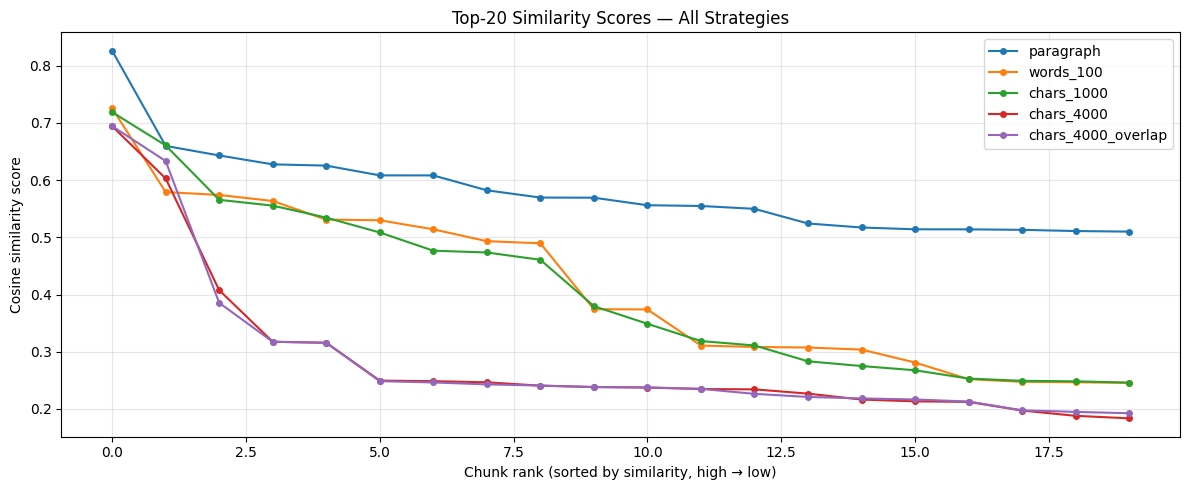

In [21]:
# --- Sorted-score line plot (top-N chunks) ---
TOP_N = 20  # change this to plot more or fewer chunks

fig, ax = plt.subplots(figsize=(12, 5))

for name, scores in strategy_scores.items():
    top = scores[:TOP_N]
    ax.plot(range(len(top)), top, marker="o", markersize=4, label=name, linewidth=1.5)

ax.set_xlabel("Chunk rank (sorted by similarity, high → low)")
ax.set_ylabel("Cosine similarity score")
ax.set_title(f"Top-{TOP_N} Similarity Scores — All Strategies")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

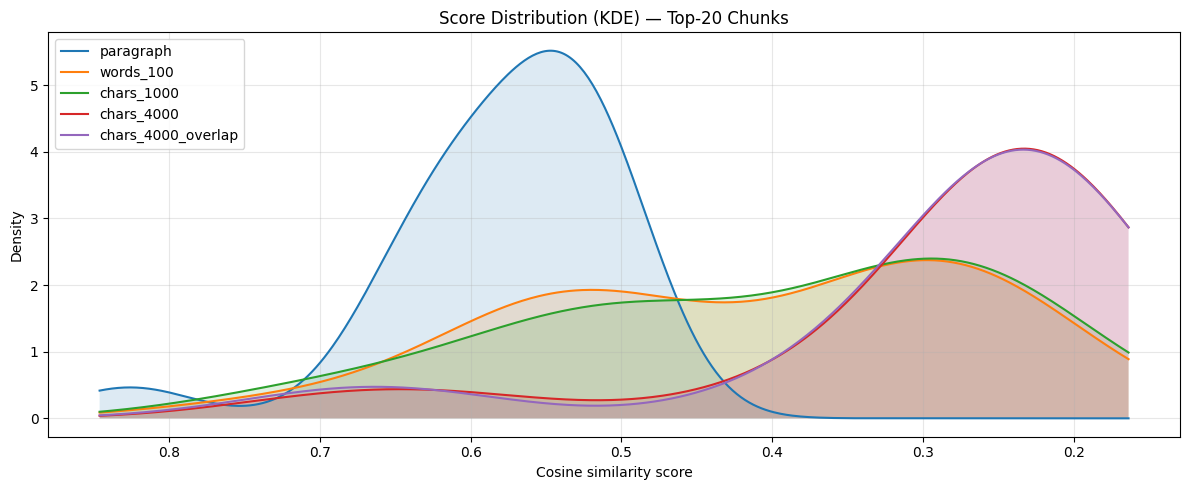

In [22]:
# --- Density plot (Gaussian KDE) of top-N chunks ---

def gaussian_kde(data, x_grid, bandwidth=None):
    """Simple Gaussian KDE using numpy (no scipy needed)."""
    data = np.asarray(data, dtype=float)
    if bandwidth is None:
        bandwidth = 1.06 * np.std(data) * len(data) ** (-1 / 5)
    if bandwidth < 1e-6:
        bandwidth = 0.01
    kernels = np.exp(-0.5 * ((x_grid[:, None] - data[None, :]) / bandwidth) ** 2)
    density = kernels.sum(axis=1) / (len(data) * bandwidth * np.sqrt(2 * np.pi))
    return density


fig, ax = plt.subplots(figsize=(12, 5))

# Use only the top-N scores
top_scores = {name: scores[:TOP_N] for name, scores in strategy_scores.items()}
all_vals = np.concatenate(list(top_scores.values()))
x_min, x_max = all_vals.min() - 0.02, all_vals.max() + 0.02
x_grid = np.linspace(x_min, x_max, 500)

for name, scores in top_scores.items():
    density = gaussian_kde(np.array(scores), x_grid)
    ax.plot(x_grid, density, label=name, linewidth=1.5)
    ax.fill_between(x_grid, density, alpha=0.15)

ax.set_xlabel("Cosine similarity score")
ax.set_ylabel("Density")
ax.set_title(f"Score Distribution (KDE) — Top-{TOP_N} Chunks")
ax.invert_xaxis()  # high similarity on the left
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 — Entropy of Retrieved Scores

**Shannon entropy** measures how "spread out" a probability distribution is.
Given the top-$N$ similarity scores $s_1, s_2, \dots, s_N$ of a chunking strategy, we first convert them into a probability distribution by normalising:

$$p_i = \frac{s_i}{\sum_{j=1}^{N} s_j}$$

Then we compute:

$$H = -\sum_{i=1}^{N} p_i \, \log_2(p_i)$$

- **Low entropy** → a few chunks dominate (scores concentrated) → the retriever is very selective.
- **High entropy** → scores are spread evenly across many chunks → the retriever is less decisive.

The maximum possible entropy for $N$ chunks is $\log_2(N)$, which occurs when all chunks have equal probability.

/tmp/ipykernel_5451/1776334835.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


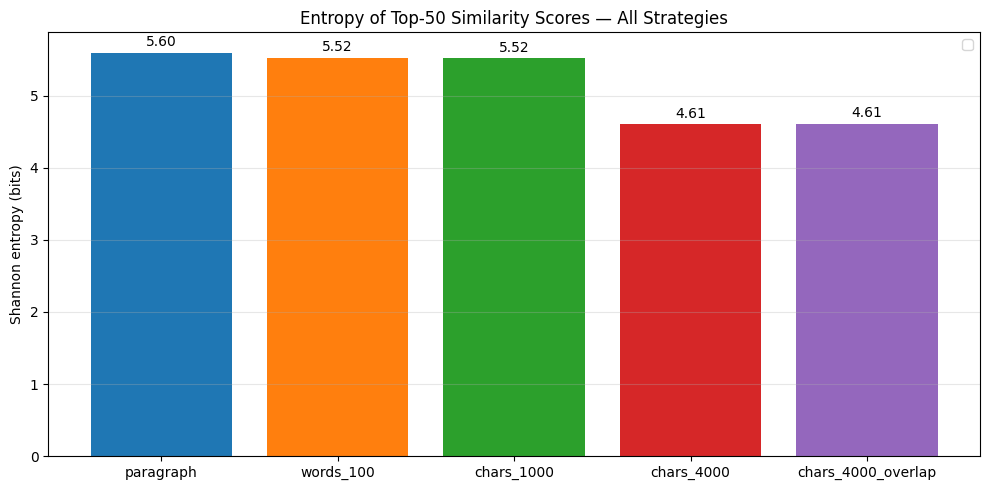

In [28]:
TOP_N=50

# --- Entropy bar chart ---

def entropy(scores, top_n=None):
    """Compute Shannon entropy (bits) of similarity scores normalised to probabilities."""
    s = np.array(scores[:top_n] if top_n else scores, dtype=float)
    s = s[s > 0]  # drop zeros to avoid log(0)
    p = s / s.sum()
    return -np.sum(p * np.log2(p))


strategy_names = list(strategy_scores.keys())
entropies = [entropy(strategy_scores[n], top_n=TOP_N) for n in strategy_names]
max_entropy = np.log2(TOP_N)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(strategy_names, entropies, color=plt.cm.tab10.colors[:len(strategy_names)])
#ax.axhline(max_entropy, color="grey", linestyle="--", linewidth=1, label=f"max entropy (log₂{TOP_N} = {max_entropy:.2f})")
ax.set_ylabel("Shannon entropy (bits)")
ax.set_title(f"Entropy of Top-{TOP_N} Similarity Scores — All Strategies")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# Annotate bars
for bar, h in zip(bars, entropies):
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f"{h:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### 3.8 — Try Your Own Query

Change `CUSTOM_QUERY` below to any question you like. The cell will:
1. Search **each** existing chunking strategy's collection for the top-$N$ most similar chunks
2. Show a **line plot**, a **density plot**, and an **entropy bar chart** — identical to the views above but for your custom query

Query: "Welche Studiengänge bietet das HPI an?"
  paragraph: 384 chunks, top score = 0.9085
  words_100: 92 chunks, top score = 0.6872
  chars_1000: 85 chunks, top score = 0.7013
  chars_4000: 27 chunks, top score = 0.7250
  chars_4000_overlap: 27 chunks, top score = 0.7244


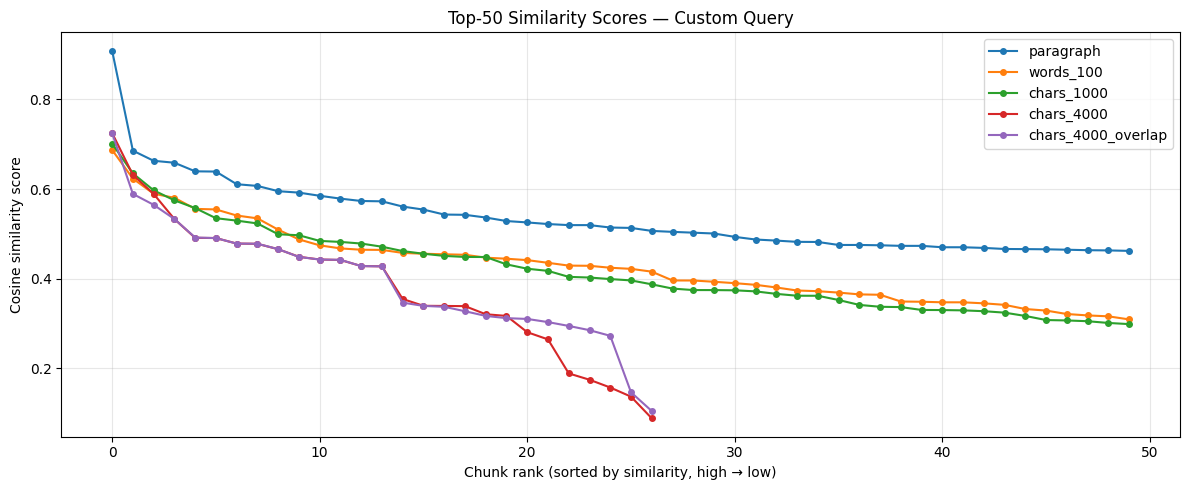

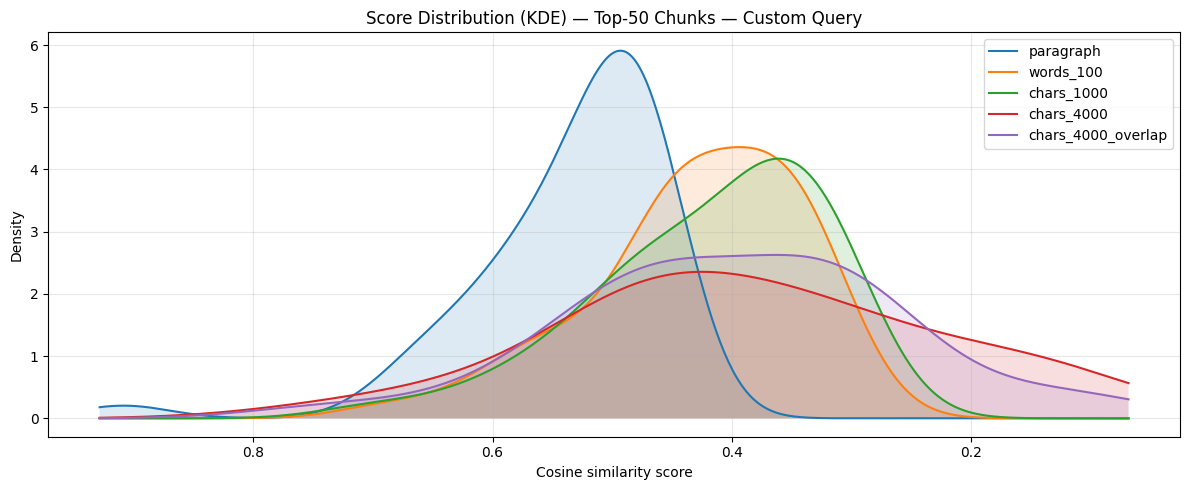

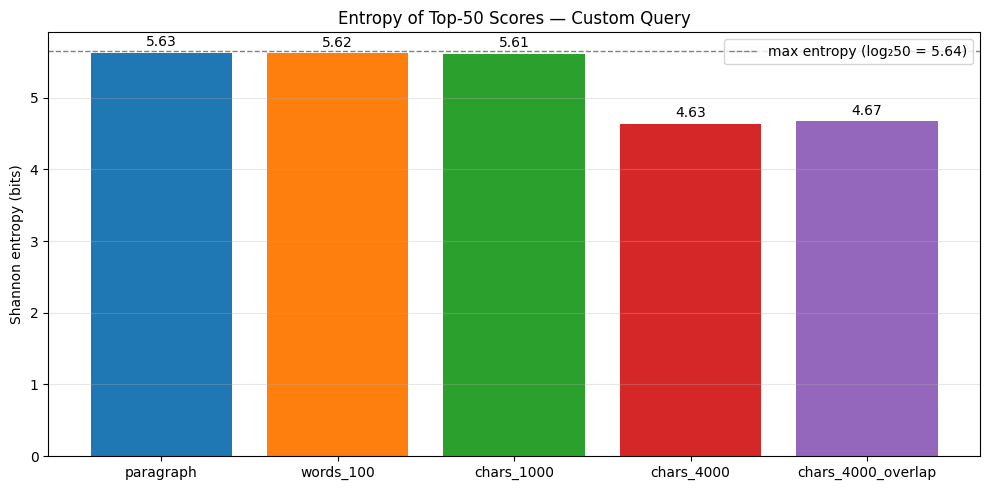

In [29]:
# ======================================================================
# ✏️  Change this query to anything you want to explore
# ======================================================================
CUSTOM_QUERY = "Welche Studiengänge bietet das HPI an?"

# --- Retrieve top-N scores from each existing strategy collection ---
STRATEGY_COLLECTIONS = {
    "paragraph":          "nb_paragraph",
    "words_100":          "nb_words_100",
    "chars_1000":         "nb_chars_1000",
    "chars_4000":         "nb_chars_4000",
    "chars_4000_overlap": "nb_chars_4000_overlap",
}

custom_scores: dict[str, list[float]] = {}
query_vector = embed(CUSTOM_QUERY)[0].tolist()

for strategy_name, collection in STRATEGY_COLLECTIONS.items():
    if not qdrant.collection_exists(collection):
        print(f"  [skip] collection '{collection}' does not exist — run the strategy cell first")
        continue
    info = qdrant.get_collection(collection)
    n_points = info.points_count
    results = qdrant.query_points(
        collection_name=collection, query=query_vector, limit=n_points
    ).points
    custom_scores[strategy_name] = sorted([r.score for r in results], reverse=True)

print(f'Query: "{CUSTOM_QUERY}"')
for name, scores in custom_scores.items():
    print(f"  {name}: {len(scores)} chunks, top score = {scores[0]:.4f}")


# ── 1. Line plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for name, scores in custom_scores.items():
    top = scores[:TOP_N]
    ax.plot(range(len(top)), top, marker="o", markersize=4, label=name, linewidth=1.5)
ax.set_xlabel("Chunk rank (sorted by similarity, high → low)")
ax.set_ylabel("Cosine similarity score")
ax.set_title(f"Top-{TOP_N} Similarity Scores — Custom Query")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── 2. Density plot (KDE) ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
top_custom = {n: s[:TOP_N] for n, s in custom_scores.items()}
all_vals = np.concatenate(list(top_custom.values()))
x_min, x_max = all_vals.min() - 0.02, all_vals.max() + 0.02
x_grid = np.linspace(x_min, x_max, 500)

for name, scores in top_custom.items():
    density = gaussian_kde(np.array(scores), x_grid)
    ax.plot(x_grid, density, label=name, linewidth=1.5)
    ax.fill_between(x_grid, density, alpha=0.15)
ax.set_xlabel("Cosine similarity score")
ax.set_ylabel("Density")
ax.set_title(f"Score Distribution (KDE) — Top-{TOP_N} Chunks — Custom Query")
ax.invert_xaxis()
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── 3. Entropy bar chart ─────────────────────────────────────────────
strategy_names_c = list(custom_scores.keys())
entropies_c = [entropy(custom_scores[n], top_n=TOP_N) for n in strategy_names_c]
max_ent = np.log2(TOP_N)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(strategy_names_c, entropies_c, color=plt.cm.tab10.colors[:len(strategy_names_c)])
#ax.axhline(max_ent, color="grey", linestyle="--", linewidth=1, label=f"max entropy (log₂{TOP_N} = {max_ent:.2f})")
ax.set_ylabel("Shannon entropy (bits)")
ax.set_title(f"Entropy of Top-{TOP_N} Scores — Custom Query")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for bar, h in zip(bars, entropies_c):
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f"{h:.2f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

---
## 4 · Exercises

Try the following on your own:

### Exercise 1 — Sentence-based chunking
Implement a chunking strategy that splits on **sentence boundaries** (e.g. `.`, `!`, `?`).  
How does it compare to paragraph-based chunking?

### Exercise 2 — Recursive / hierarchical chunking
Try splitting first by `##` headings, then by paragraphs within each section.  
Does preserving document structure improve retrieval?

### Exercise 3 — Tune overlap
Experiment with different overlap values (0, 100, 500, 1000) for 4000-char chunks.  
Is there a sweet spot?

# TODO: Implement your own chunking strategies and compare

---
## 5 · Cleanup

Delete the collections we created so they don't interfere with the main application.

In [30]:
# Uncomment to delete all strategy collections:
# for name in ["nb_paragraph", "nb_words_100", "nb_chars_1000", "nb_chars_4000", "nb_chars_4000_overlap"]:
#     if qdrant.collection_exists(name):
#         qdrant.delete_collection(name)
#         print(f"Deleted '{name}'")